In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import os
import sys

sys.path.append(os.path.abspath(".."))

from libs import displacement as dpm
from libs import fit_model as fm 
from libs import cal_vel as cv

plt.style.use('../libs/my_style.mplstyle')

markers = ["o", "s", "v", "^", '*', 'd']
lines = ["-", "--", "-.", ":", (0, (5, 3, 1, 3, 1, 3))]

scale = 0.11
interval = 10

def get_wait(path):
    track = cv.cal(pd.read_csv(path),scale=scale ,frame_interval=interval)
    wt = cv.low_area(track, threshold=0.015, min_low_duration=1,time_interval=interval, xlabel = 'time(sec)', ylabel = 'velocity(um/s)', ylim = (0.0, 0.7), display = False)
    tt = cv.pulses(track, threshold=0.015, time_interval=interval, display = False)

    return wt, tt

In [ ]:
path1 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20240910/MC03MT083uM/beads_tracks.csv"
path2 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20240910/MC03MT083uM001/beads_tracks.csv"
path3 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20240926/MC03MT1uM/beads_tracks.csv"
path4 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20241127/MC03MT1uM/beads_tracks.csv"

MC103 = [path1, path2, path3, path4]


MC103_wt = []
MC103_tt = []

i = 0
for path in MC103:
    wt, tt = get_wait(path)
    wt['particle'] += i*10000
    tt['particle'] += i*10000
    MC103_wt.append(wt)
    MC103_tt.append(tt)
    i += 1

MC103_wt = pd.concat(MC103_wt)
MC103_tt = pd.concat(MC103_tt)

/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tracking_df[['v', 'theta']] = tracking_df.groupby('particle').apply(
/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tracking_df[['v', 'theta']] = tracking_df.groupby('particle').apply(
/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:39: Futu

<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:27: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:27: SyntaxWarning: invalid escape sequence '\p'
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_20163/1964090981.py:26: SyntaxWarning: invalid escape sequence '\p'
  ax.text(100, 1e-2, '$\propto \Delta t ^{-2}$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_20163/1964090981.py:27: SyntaxWarning: invalid escape sequence '\p'
  ax.text(20, 5*1e-5, '$\propto \Delta t ^{-3}$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_20163/1964090981.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(fm.ln_pl, np.log10(bin_edges[indices]), np.log10(counts[indices]))
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_20163/1964090981.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore a

"\nfig.savefig(f'{output}_{d_today}.pdf', bbox_inches='tight')\nfig.savefig(f'{output}_{d_today}.png', bbox_inches='tight')\n"

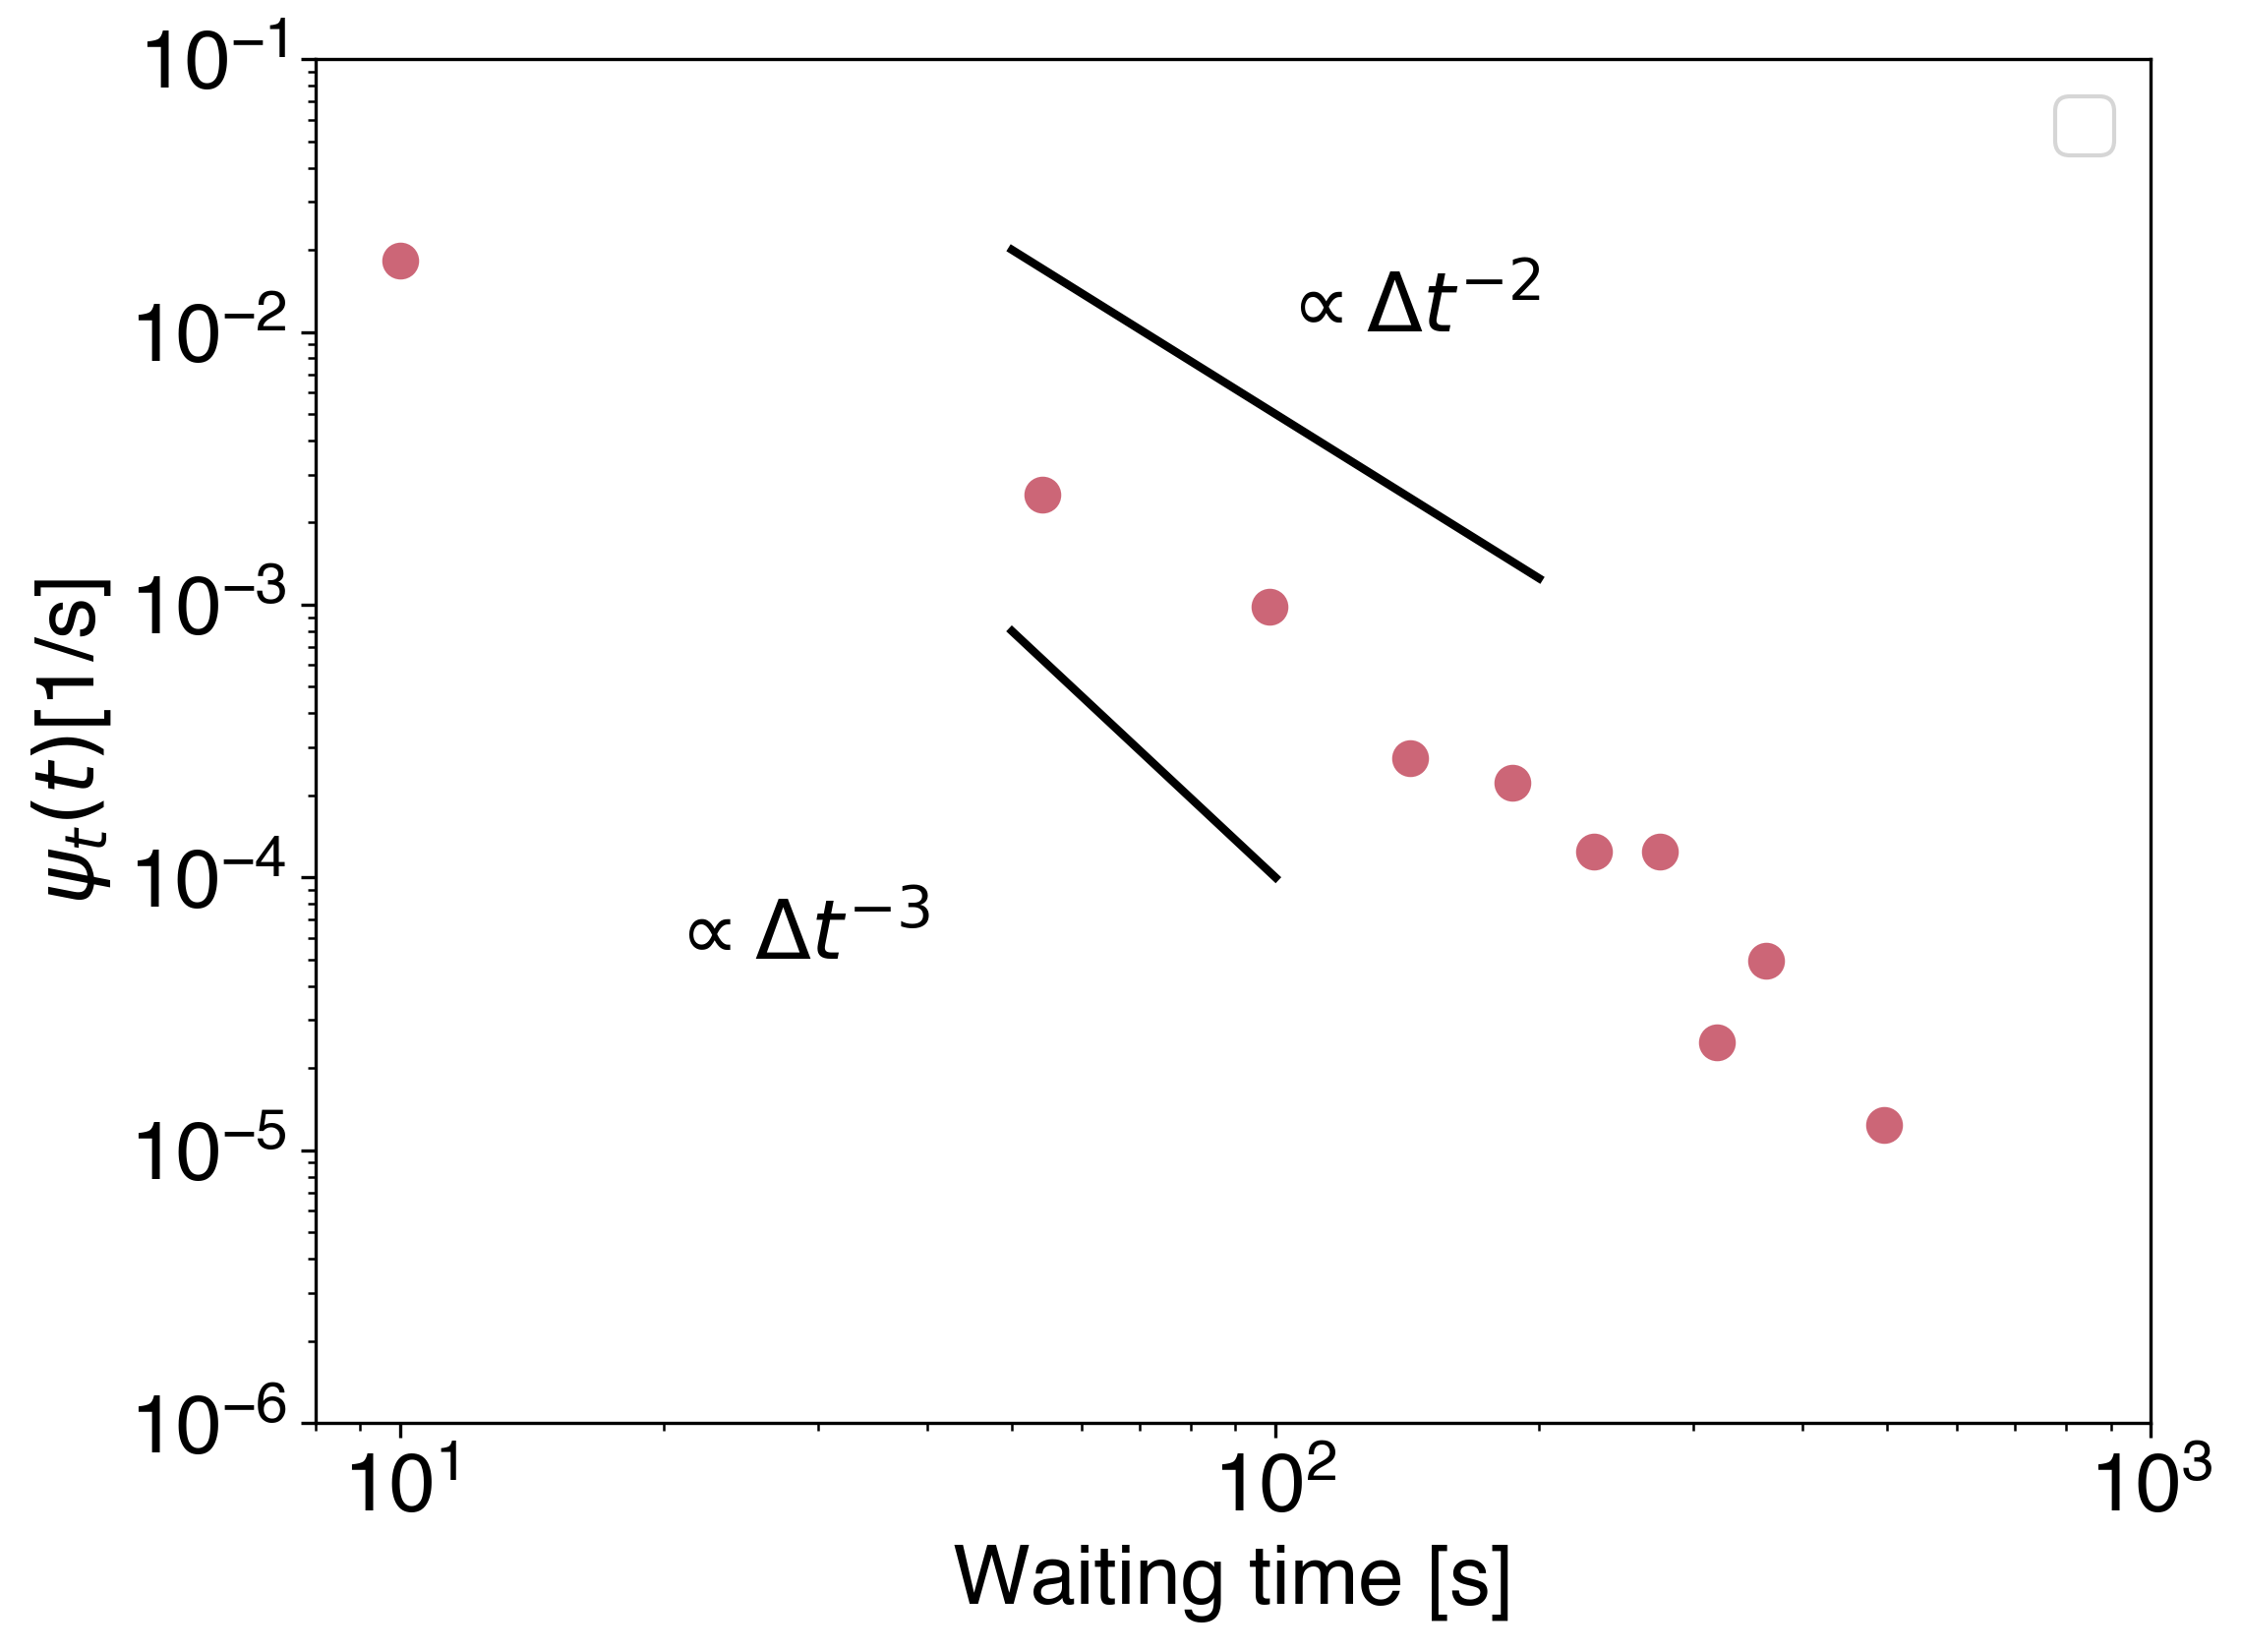

In [25]:
min_fit, max_fit = 50,110

def get_hist(df, min_fit, max_fit, marker, label=None):
    data = df['interval'].values
    # ヒストグラムのデータを計算
    bins = np.histogram_bin_edges(data, 'sturges')
    counts, bin_edges = np.histogram(data, bins, density = True)
    indices = np.where((counts>0) & (bin_edges[:-1]>=min_fit) & (bin_edges[:-1]<=max_fit))
    popt, pcov = curve_fit(fm.ln_pl, np.log10(bin_edges[indices]), np.log10(counts[indices]))
    fit = fm.power_law(bins, popt[0], popt[1])
    ax.scatter(bin_edges[:-1], counts, marker=markers[marker], label = label)
    #ax.plot(bins, fit, color = colors[color], lw = lw, linestyle=lines[line])
    #print(f"MT{MT_conc[MT]}uM MC{mc_conc[mc]}%, {np.abs(popt[0]+1)}")
    
    return counts, bin_edges, popt, pcov

fig, ax  = plt.subplots()

counts, bin_edges, popt, _ = get_hist(MC03_wt, min_fit, max_fit, marker=0)

ty = np.linspace(50, 200, 10)
ax.plot(ty, 5*1e1*ty**-2, color = 'black', lw=2)
ty2 = np.linspace(50, 100, 10)
ax.plot(ty2, 1e2*ty2**-3, color = 'black', lw=2)

ax.text(100, 1e-2, '$\propto \Delta t ^{-2}$')
ax.text(20, 5*1e-5, '$\propto \Delta t ^{-3}$')

ax.legend()

ax.set(xlim=(0.8*1e1,1000),
       ylim=(1e-6, 1e-1),
       xscale='log',
       yscale = 'log',
       xlabel = 'Waiting time [s]',
       ylabel = '$\\psi_t(t)$[1/s]')
"""
fig.savefig(f'{output}_{d_today}.pdf', bbox_inches='tight')
fig.savefig(f'{output}_{d_today}.png', bbox_inches='tight')
"""

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_20163/2905873738.py:11: SyntaxWarning: invalid escape sequence '\p'
  ax.text(100, 1e-2, '$\propto \Delta t ^{-1}$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_20163/2905873738.py:12: SyntaxWarning: invalid escape sequence '\p'
  ax.text(20, 5*1e-5, '$\propto \Delta t ^{-2}$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_20163/1964090981.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(fm.ln_pl, np.log10(bin_edges[indices]), np.log10(counts[indices]))


[(8.0, 1000.0),
 (1e-06, 0.1),
 None,
 None,
 Text(0.5, 0, 'Waiting time [s]'),
 Text(0, 0.5, '$\\psi_r(t)$[1/s]')]

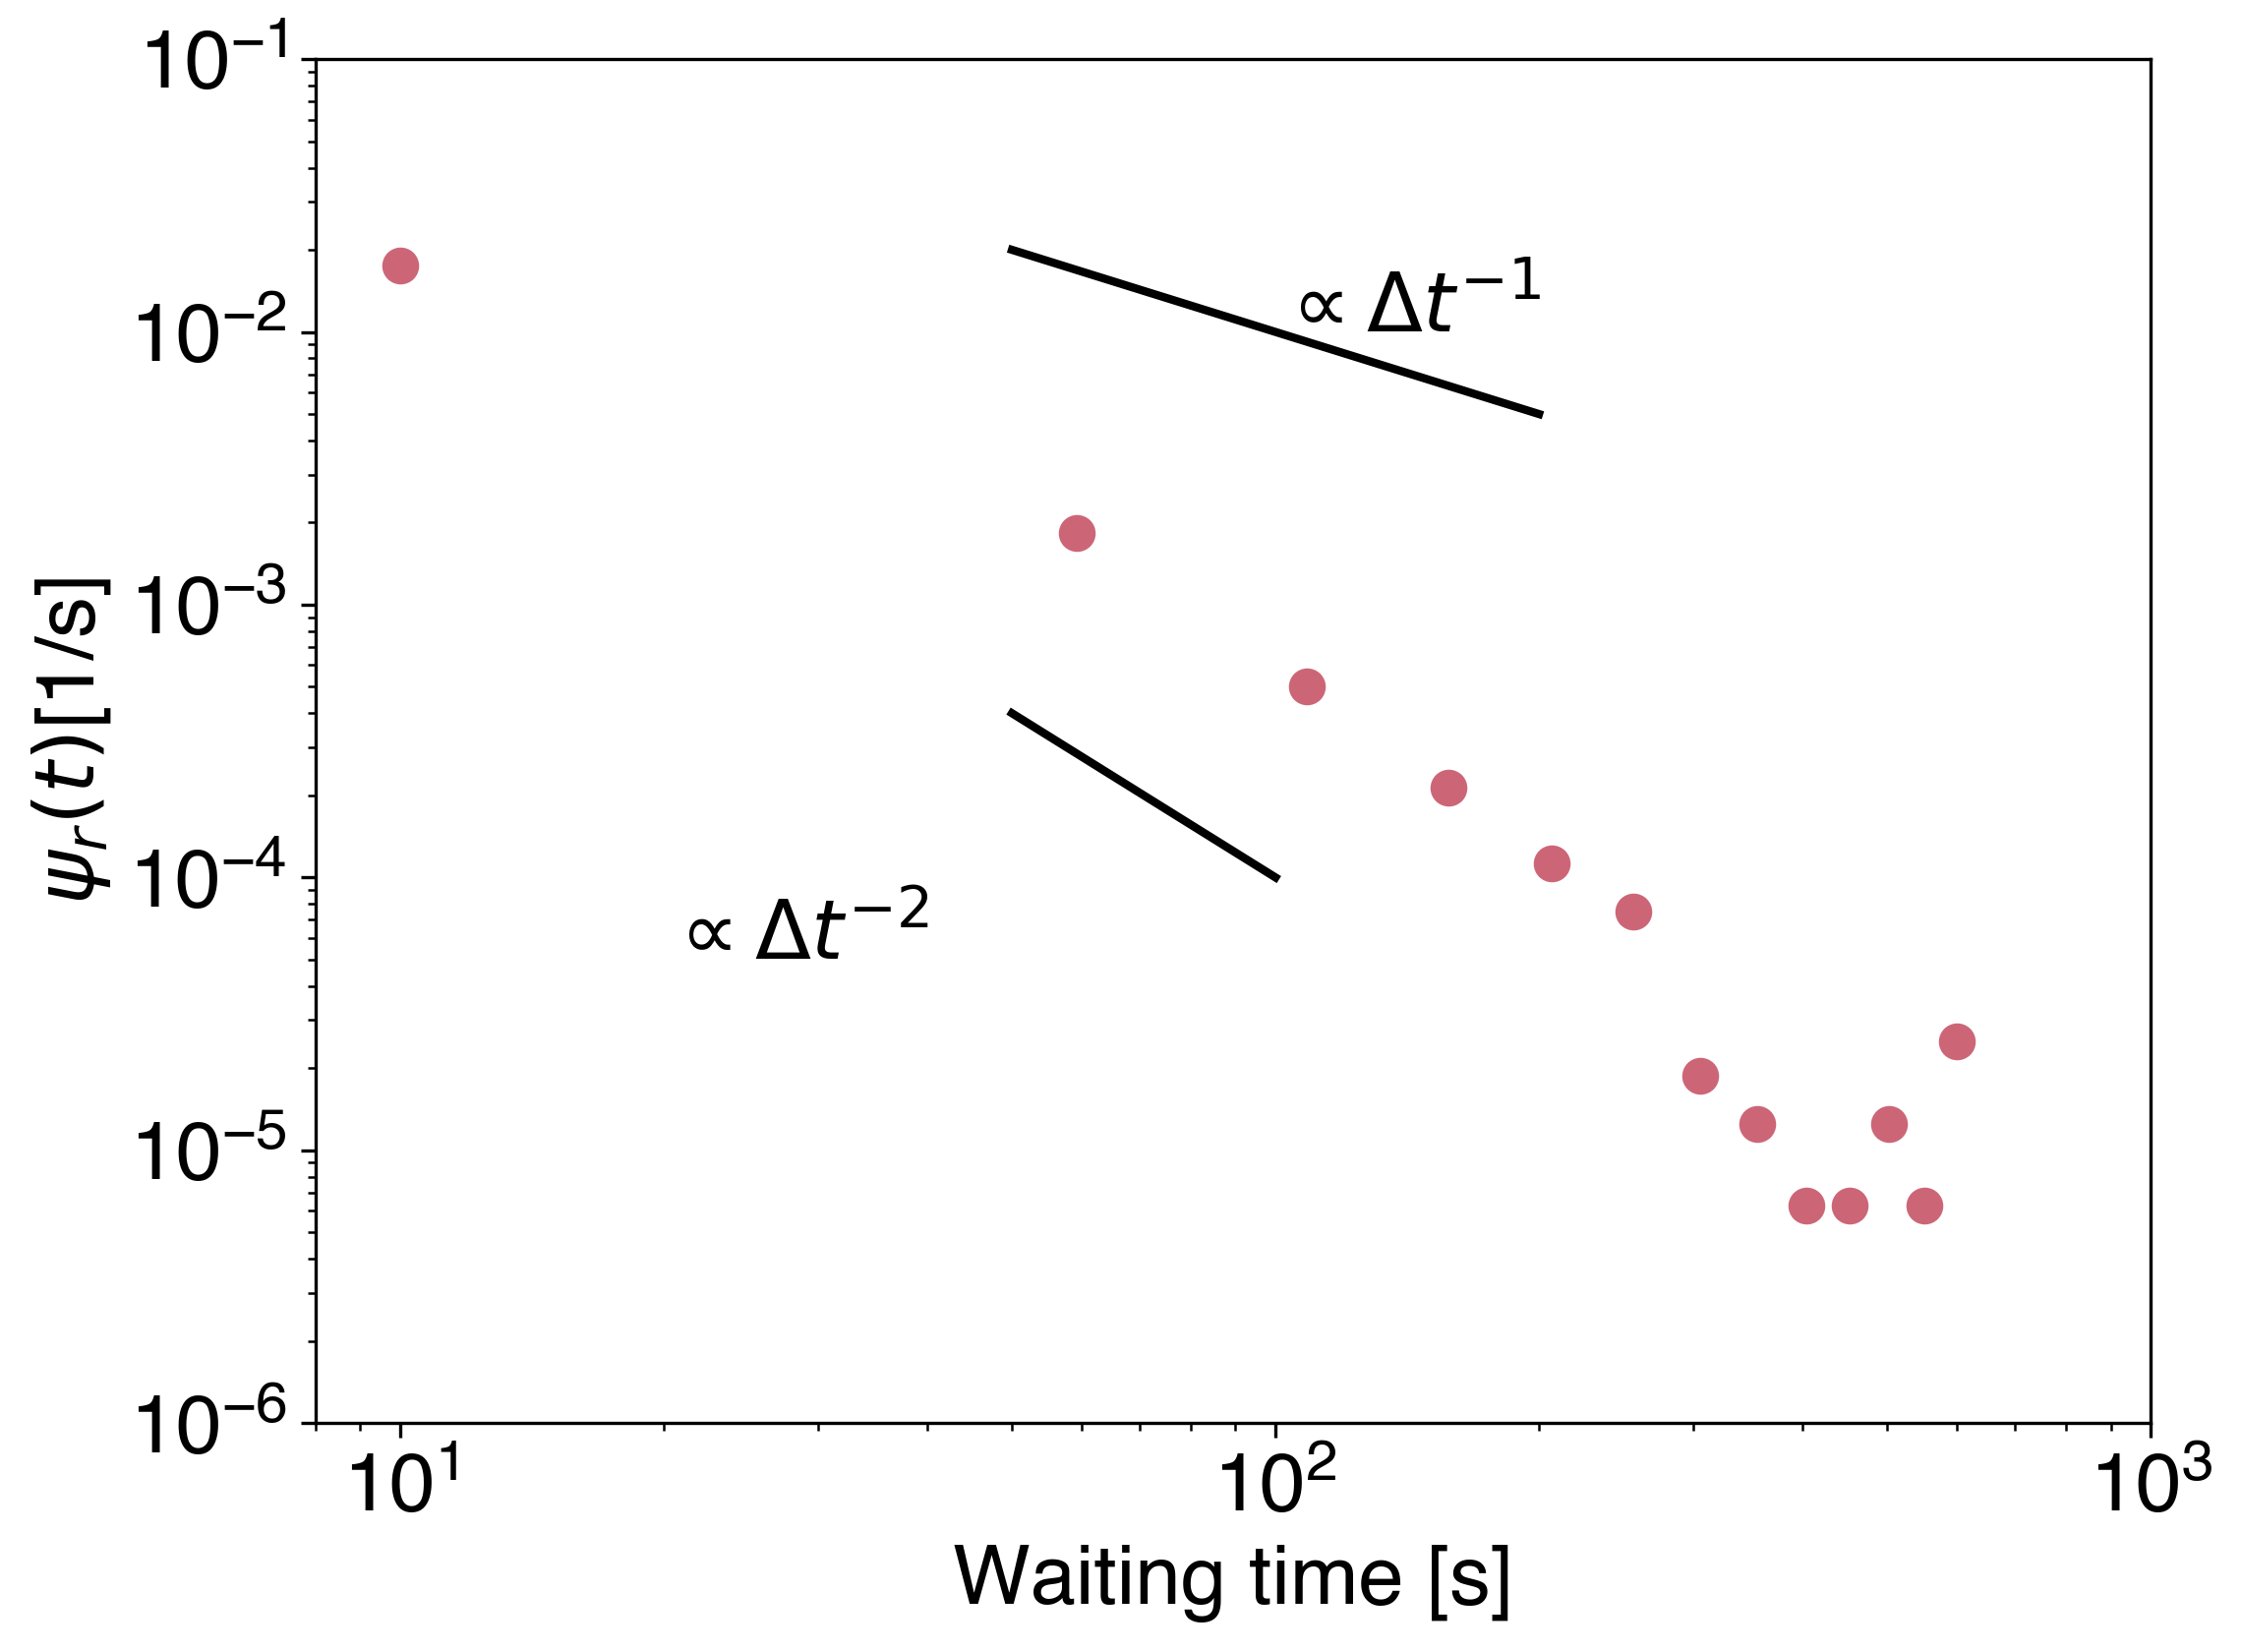

In [27]:
min_fit, max_fit = 50,110
fig, ax  = plt.subplots()

counts, bin_edges, popt, _ = get_hist(MC03_tt, min_fit, max_fit, marker=0)

ty = np.linspace(50, 200, 10)
ax.plot(ty, 1e0*ty**-1, color = 'black', lw=2)
ty2 = np.linspace(50, 100, 10)
ax.plot(ty2, 1e0*ty2**-2, color = 'black', lw=2)

ax.text(100, 1e-2, '$\propto \Delta t ^{-1}$')
ax.text(20, 5*1e-5, '$\propto \Delta t ^{-2}$')

ax.set(xlim=(0.8 * 1e1,1000),
       ylim=(1e-6, 1e-1),
       xscale='log',
       yscale = 'log',
       xlabel = 'Waiting time [s]',
       ylabel = '$\\psi_r(t)$[1/s]')